# 12 — Controls for headline LOSO + seed stability

This notebook runs three sanity checks on the headlines from notebook 11:

**Headlines** (from nb 11):
- **Tabular:** DeepSets on `A1+B+C1+D1`  →  LOSO bal_acc = **0.515 ± 0.019**
- **Tier G:**  HGB on the 116-D oracle fingerprint  →  LOSO bal_acc = **0.533 ± 0.048**

**Controls in this notebook**
1. **Scan-identity-only LOSO.** Features = `session_key` one-hot + `scan_idx`. Under
   GKF this leaks; under LOSO the held-out session's one-hot column is all-zero
   in train, so the model has no information. *Expected: ~chance (0.25).*
2. **cc_abs-only LOSO.** Features = `cc_abs` (single per-neuron column). Tests
   whether the headline accuracy is mostly explained by response reliability /
   signal quality rather than biological tuning.
3. **Random-seed stability.** Re-run the two headline LOSO loops with 5 seeds
   each, report mean ± std across seeds.

Same population as nb 11: consistent neurons (cell-type ↔ layer agree), oracle
hashes only, well-behaved sessions only (`5_6, 5_7, 6_2, 6_4, 6_6`), 4-class
layer decoding (chance = 0.25).


In [1]:
from __future__ import annotations
import sys, time, gc, pickle, warnings
from pathlib import Path

if '..' not in sys.path:
    sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import balanced_accuracy_score
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

from src.config import (
    PROCESSED_TABLES_DIR, PROCESSED_FEATURES_DIR, PROCESSED_RESULTS_DIR,
    FIGURES_DIR, RANDOM_SEED, ensure_dirs,
)
from src.features.tier_b import B_FEATURE_NAMES
from src.features.tier_c import C1_FEATURE_NAMES
from src.features.tier_d import D_FEATURE_NAMES
from src.models.deep_sets import DeepSets

ensure_dirs()
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

CLASSES         = np.array(['L2/3', 'L4', 'L5', 'L6'])
label_to_idx    = {c: i for i, c in enumerate(CLASSES)}
MIN_CLASS_COUNT = 20
N_EPOCHS_DS     = 25
DS_PATIENCE     = 5
BATCH_SIZE_DS   = 64
N_SEEDS         = 5
SEEDS           = [42, 7, 13, 101, 2024]

CELL_TYPE_TO_LAYER = {
    '23P': 'L2/3', '4P': 'L4',
    '5P-IT': 'L5', '5P-ET': 'L5', '5P-NP': 'L5',
    '6P-IT': 'L6', '6P-CT': 'L6',
}
STIM_OHE  = ['d_stim_Clip', 'd_stim_Monet2', 'd_stim_Trippy']
D_NUMERIC = list(D_FEATURE_NAMES)

print(f'Setup ok. SEEDS={SEEDS}')


Setup ok. SEEDS=[42, 7, 13, 101, 2024]


## 1. Reproduce population (consistent + well-behaved)

In [2]:
# Oracle hashes
oracle_data   = pickle.load(open(PROCESSED_TABLES_DIR.parent / 'oracle_hashes.pkl', 'rb'))
ORACLE_HASHES = set(oracle_data['oracle_hashes'])

# Consistent neurons
units = pd.read_parquet(PROCESSED_TABLES_DIR / 'units_working.parquet')
units['consistent'] = (units['celltype_label'].map(CELL_TYPE_TO_LAYER) == units['layer_label'])
units_clean = units[units['consistent']].copy()
consistent_ids = set(units_clean['nucleus_id'])

# Well-behaved sessions
rows = []
for sk, grp in units_clean.groupby('session_key'):
    cnt = grp['layer_label'].value_counts().reindex(CLASSES, fill_value=0)
    rows.append({'session_key': sk, 'well_behaved': bool((cnt >= MIN_CLASS_COUNT).all())})
df_sess = pd.DataFrame(rows).sort_values('session_key')
WELL_BEHAVED = list(df_sess[df_sess['well_behaved']]['session_key'])
print(f'Well-behaved: {WELL_BEHAVED}')

# Per-neuron table (consistent + well-behaved + with cc_abs/scan_idx)
units_wb = units_clean[units_clean['session_key'].isin(WELL_BEHAVED)].copy()
print(f'Population: {len(units_wb):,} neurons across {len(WELL_BEHAVED)} sessions')

# Quick label distribution
print()
print('Layer distribution (well-behaved pool):')
print(units_wb['layer_label'].value_counts().reindex(CLASSES).to_string())


Well-behaved: ['5_6', '5_7', '6_2', '6_4', '6_6']
Population: 3,545 neurons across 5 sessions

Layer distribution (well-behaved pool):
layer_label
L2/3    1456
L4       959
L5       841
L6       289


## 2. Build tabular long-row table (A1+B+C1+D1) and Tier G

Reuses the same logic as notebook 11. We need the long-row tabular table for
the DeepSets seed-stability sweep and the per-neuron Tier G table for the
HGB-TierG seed-stability sweep.

In [3]:
# A1 amp + shape
print('Loading A1_amp ...')
a1_amp = pd.read_parquet(PROCESSED_FEATURES_DIR / 'A1_amp.parquet')
a1_amp = a1_amp[a1_amp['condition_hash'].isin(ORACLE_HASHES) &
                a1_amp['nucleus_id'].isin(consistent_ids) &
                a1_amp['session_key'].isin(WELL_BEHAVED)].copy()
AMP_COLS = [c for c in a1_amp.columns if c.startswith('amp_')]

print('Loading A1_shape ...')
a1_shape = pd.read_parquet(PROCESSED_FEATURES_DIR / 'A1_shape.parquet')
a1_shape = a1_shape[a1_shape['condition_hash'].isin(ORACLE_HASHES) &
                    a1_shape['nucleus_id'].isin(consistent_ids) &
                    a1_shape['session_key'].isin(WELL_BEHAVED)].copy()
SHAPE_COLS = [c for c in a1_shape.columns if c.startswith('shape_')]

key_cols = ['nucleus_id','condition_hash','session_key']
df_base = a1_amp.merge(a1_shape[key_cols + SHAPE_COLS],
                        on=key_cols, how='inner', validate='one_to_one')
A1_COLS = AMP_COLS + SHAPE_COLS
del a1_amp, a1_shape; gc.collect()

# B
b = pd.read_parquet(PROCESSED_FEATURES_DIR / 'B_per_hash.parquet')
b = b[b['condition_hash'].isin(ORACLE_HASHES) &
      b['nucleus_id'].isin(consistent_ids) &
      b['session_key'].isin(WELL_BEHAVED)]
B_COLS = [c for c in b.columns if c.startswith('b_')]
df_base = df_base.merge(b[key_cols + B_COLS], on=key_cols, how='inner')
del b; gc.collect()

# C1
c1 = pd.read_parquet(PROCESSED_FEATURES_DIR / 'C1_per_hash.parquet')
c1 = c1[c1['condition_hash'].isin(ORACLE_HASHES) &
         c1['nucleus_id'].isin(consistent_ids) &
         c1['session_key'].isin(WELL_BEHAVED)]
C1_COLS = [c for c in c1.columns if c.startswith('c1_')]
df_base = df_base.merge(c1[key_cols + C1_COLS], on=key_cols, how='left')
del c1; gc.collect()

# D
d = pd.read_parquet(PROCESSED_FEATURES_DIR / 'D_per_hash.parquet')
for fam in ['Clip','Monet2','Trippy']:
    d[f'd_stim_{fam}'] = (d['stim_type'] == fam).astype(np.float32)
D_COLS = D_NUMERIC + STIM_OHE
df_base = df_base.merge(d[['condition_hash'] + D_COLS], on='condition_hash', how='left')
del d; gc.collect()

# Attach layer label
label_map = units_clean.set_index('nucleus_id')['layer_label'].to_dict()
df_base['layer_label'] = df_base['nucleus_id'].map(label_map)
HEADLINE_FEATS = A1_COLS + B_COLS + C1_COLS + D_COLS
print(f'\nLong-row tabular table: {df_base.shape}  ({len(HEADLINE_FEATS)} features)')

# Tier G (per-neuron)
g_wide = pd.read_parquet(PROCESSED_FEATURES_DIR / 'G_per_neuron.parquet')
G_COLS = [c for c in g_wide.columns if c.startswith('g_')]
g_wide = g_wide[g_wide['nucleus_id'].isin(consistent_ids)].copy()
g_wide['layer_label'] = g_wide['nucleus_id'].map(label_map)
g_wide['session_key'] = g_wide['nucleus_id'].map(
    units_clean.set_index('nucleus_id')['session_key'].to_dict())
df_g = g_wide[g_wide['session_key'].isin(WELL_BEHAVED)].copy()
print(f'Tier G: {df_g.shape}  ({len(G_COLS)} features)')
del g_wide; gc.collect()

# Per-neuron table for scan-only / cc_abs-only controls
df_neur = (units_wb[['nucleus_id','session_key','scan_idx','cc_abs','layer_label',
                       'pt_position_x','pt_position_y','pt_position_z']]
           .drop_duplicates('nucleus_id').reset_index(drop=True))
print(f'Per-neuron control table: {df_neur.shape}')


Loading A1_amp ...
Loading A1_shape ...

Long-row tabular table: (411220, 51)  (44 features)
Tier G: (3545, 119)  (116 features)
Per-neuron control table: (3545, 8)


## 3. Scan-identity-only LOSO

Features:
- `session_key` one-hot (5 columns; held-out session's column is **always zero**
  in training because it doesn't appear in the train set)
- `scan_idx` (small numeric integer; values may overlap across sessions)

Under LOSO this is essentially a no-information control. If the model still
predicts above chance (0.25) it must be using overlapping `scan_idx` values
which carry incidental info — but the prediction should be far below the
headline.

In [4]:
# Build scan-only feature matrix
session_dummies = pd.get_dummies(df_neur['session_key'], prefix='sess').astype(np.float32)
SCAN_COLS = list(session_dummies.columns) + ['scan_idx']
X_scan_full = pd.concat([session_dummies, df_neur[['scan_idx']].astype(np.float32)], axis=1)
print(f'Scan-only features: {SCAN_COLS}')
print(f'X shape: {X_scan_full.shape}')

def loso_simple(X, y, sk, model_name, seed=0):
    rows = []
    for held_out in WELL_BEHAVED:
        tr = sk != held_out
        te = sk == held_out
        X_tr, y_tr = X[tr], y[tr]
        X_te, y_te = X[te], y[te]
        if model_name == 'LogReg':
            clf = Pipeline([
                ('impute', SimpleImputer(strategy='median')),
                ('scale',  RobustScaler()),
                ('clf',    LogisticRegression(class_weight='balanced',
                            max_iter=500, solver='lbfgs', random_state=seed)),
            ])
            clf.fit(X_tr, y_tr)
            y_pred = clf.predict(X_te)
        else:
            clf = HistGradientBoostingClassifier(
                max_iter=100, max_depth=6, learning_rate=0.05,
                l2_regularization=1.0, early_stopping=True, n_iter_no_change=10,
                random_state=seed)
            sw = compute_sample_weight('balanced', y_tr)
            clf.fit(X_tr, y_tr, sample_weight=sw)
            y_pred = clf.predict(X_te)
        ba = balanced_accuracy_score(y_te, y_pred)
        per_class = {c: float((y_pred[y_te==c] == c).mean()) if (y_te==c).any()
                     else np.nan for c in CLASSES}
        rows.append({'held_out': held_out, 'balanced_accuracy': ba,
                     **{f'recall_{c}': per_class[c] for c in CLASSES}})
    return pd.DataFrame(rows)

X = X_scan_full.to_numpy(dtype=np.float64)
y = df_neur['layer_label'].to_numpy()
sk = df_neur['session_key'].to_numpy()

scan_results = []
for model_name in ['LogReg', 'HGB']:
    t0 = time.time()
    r = loso_simple(X, y, sk, model_name)
    r['model'] = model_name
    scan_results.append(r)
    print(f'\n── Scan-only / {model_name}  ({time.time()-t0:.1f}s) ──')
    print(r[['held_out','balanced_accuracy']].to_string(index=False))
    print(f'  mean: {r["balanced_accuracy"].mean():.3f} ± {r["balanced_accuracy"].std():.3f}')

scan_results = pd.concat(scan_results, ignore_index=True)
scan_results.to_parquet(PROCESSED_RESULTS_DIR / 'nb12_scan_only_loso.parquet')


Scan-only features: ['sess_5_6', 'sess_5_7', 'sess_6_2', 'sess_6_4', 'sess_6_6', 'scan_idx']
X shape: (3545, 6)

── Scan-only / LogReg  (0.1s) ──
held_out  balanced_accuracy
     5_6               0.25
     5_7               0.25
     6_2               0.25
     6_4               0.25
     6_6               0.25
  mean: 0.250 ± 0.000

── Scan-only / HGB  (1.0s) ──
held_out  balanced_accuracy
     5_6               0.25
     5_7               0.25
     6_2               0.25
     6_4               0.25
     6_6               0.25
  mean: 0.250 ± 0.000


## 4. cc_abs-only LOSO

`cc_abs` is the per-neuron oracle correlation — a measure of response
reliability. Per-neuron, single column. If a model can predict layer just from
`cc_abs`, then the headline accuracy may be mostly tracking signal quality
rather than tuning.


── cc_abs-only / LogReg  (0.1s) ──
held_out  balanced_accuracy
     5_6           0.375263
     5_7           0.363446
     6_2           0.387863
     6_4           0.286935
     6_6           0.369435
  mean: 0.357 ± 0.040

── cc_abs-only / HGB  (2.7s) ──
held_out  balanced_accuracy
     5_6           0.358076
     5_7           0.339108
     6_2           0.318434
     6_4           0.301135
     6_6           0.370360
  mean: 0.337 ± 0.028


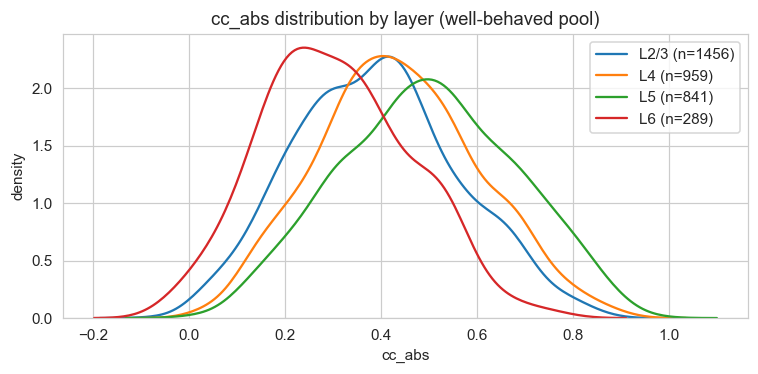

In [5]:
X_cc = df_neur[['cc_abs']].to_numpy(dtype=np.float64)

cc_results = []
for model_name in ['LogReg', 'HGB']:
    t0 = time.time()
    r = loso_simple(X_cc, y, sk, model_name)
    r['model'] = model_name
    cc_results.append(r)
    print(f'\n── cc_abs-only / {model_name}  ({time.time()-t0:.1f}s) ──')
    print(r[['held_out','balanced_accuracy']].to_string(index=False))
    print(f'  mean: {r["balanced_accuracy"].mean():.3f} ± {r["balanced_accuracy"].std():.3f}')

cc_results = pd.concat(cc_results, ignore_index=True)
cc_results.to_parquet(PROCESSED_RESULTS_DIR / 'nb12_cc_abs_only_loso.parquet')

# Quick view: cc_abs distribution by layer
fig, ax = plt.subplots(figsize=(7, 3.5))
for c in CLASSES:
    sub = df_neur[df_neur['layer_label'] == c]['cc_abs']
    sns.kdeplot(sub, label=f'{c} (n={len(sub)})', ax=ax)
ax.set_xlabel('cc_abs'); ax.set_ylabel('density')
ax.set_title('cc_abs distribution by layer (well-behaved pool)')
ax.legend()
plt.tight_layout(); plt.show()


## 5. Seed stability — DeepSets headline (A1+B+C1+D1)

We re-run the headline DeepSets LOSO with 5 different seeds. Each seed controls:
- `torch.manual_seed` (model weight init)
- the `np.random` RNG used to pick the in-training val split inside the runner
- the HGB `random_state` is unused here (DeepSets only)

Per-session z-scoring is identical to nb 11. Total: 5 seeds × 5 held-out
sessions = 25 fits.

In [6]:
def per_session_zscore(X, session_keys):
    X_out = X.copy().astype(np.float64)
    for s in np.unique(session_keys):
        m = session_keys == s
        X_out[m] = RobustScaler().fit_transform(X_out[m])
    return X_out

def run_deepsets(X_tr, y_tr, g_tr, X_te, y_te, g_te, seed: int,
                  n_epochs=N_EPOCHS_DS, patience=DS_PATIENCE):
    rng_np = np.random.default_rng(seed)
    torch.manual_seed(seed)

    imp = SimpleImputer(strategy='median').fit(X_tr)
    X_tr_imp = imp.transform(X_tr).astype(np.float32)
    X_te_imp = imp.transform(X_te).astype(np.float32)

    def build_tensor(X_imp, y_arr, g_arr):
        order = np.argsort(g_arr, kind='stable')
        Xs = X_imp[order]; ys = y_arr[order]; gs = g_arr[order]
        starts = np.where(np.diff(np.concatenate([[gs[0]-1], gs])))[0]
        max_set = max(ends - st for st, ends in
                      zip(starts, list(starts[1:]) + [len(gs)]))
        n_neur = len(starts); n_feat = X_imp.shape[1]
        tensor = np.zeros((n_neur, max_set, n_feat), dtype=np.float32)
        mask   = np.zeros((n_neur, max_set), dtype=np.float32)
        y_neur = np.zeros(n_neur, dtype=np.int64)
        for idx, st in enumerate(starts):
            en = starts[idx+1] if idx+1 < len(starts) else len(gs)
            tensor[idx, :en-st] = Xs[st:en]
            mask[idx, :en-st]   = 1.0
            y_neur[idx]         = label_to_idx.get(ys[st], 0)
        return (torch.from_numpy(tensor), torch.from_numpy(mask),
                torch.from_numpy(y_neur))

    Xtr_t, Mtr_t, Ytr_t = build_tensor(X_tr_imp, y_tr, g_tr)
    Xte_t, Mte_t, Yte_t = build_tensor(X_te_imp, y_te, g_te)

    n_feat = X_tr_imp.shape[1]
    model = DeepSets(n_features=n_feat, n_classes=len(CLASSES),
                     enc_hidden=64, head_hidden=64, dropout=0.1)

    cw_np = compute_sample_weight('balanced', Ytr_t.numpy())
    cw_per_class = np.zeros(len(CLASSES), dtype=np.float32)
    for c in range(len(CLASSES)):
        m = Ytr_t.numpy() == c
        if m.any(): cw_per_class[c] = float(cw_np[m].mean())
    cw_tensor = torch.from_numpy(cw_per_class)

    n_tr = Xtr_t.shape[0]
    n_val = max(1, int(n_tr * 0.10))
    val_idx = rng_np.choice(n_tr, n_val, replace=False)
    tr_idx  = np.setdiff1d(np.arange(n_tr), val_idx)

    Xv_t, Mv_t, Yv_t = Xtr_t[val_idx], Mtr_t[val_idx], Ytr_t[val_idx]
    Xt_t, Mt_t, Yt_t = Xtr_t[tr_idx],  Mtr_t[tr_idx],  Ytr_t[tr_idx]

    optim   = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss(weight=cw_tensor)

    best_val, no_improve, best_state = float('inf'), 0, None
    for epoch in range(n_epochs):
        model.train()
        perm = torch.randperm(len(tr_idx),
                              generator=torch.Generator().manual_seed(seed + epoch))
        for i in range(0, len(tr_idx), BATCH_SIZE_DS):
            b_idx = perm[i:i+BATCH_SIZE_DS]
            logits = model(Xt_t[b_idx], Mt_t[b_idx])
            loss   = loss_fn(logits, Yt_t[b_idx])
            optim.zero_grad(); loss.backward(); optim.step()
        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(Xv_t, Mv_t), Yv_t).item()
        if val_loss < best_val - 1e-4:
            best_val, no_improve = val_loss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
        if no_improve >= patience:
            break
    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        proba = torch.softmax(model(Xte_t, Mte_t), dim=-1).numpy()
    y_pred = proba.argmax(axis=1)
    y_true = Yte_t.numpy()
    ba = balanced_accuracy_score(y_true, y_pred)
    per_class = {}
    for ci, c in enumerate(CLASSES):
        m = y_true == ci
        if m.any(): per_class[c] = float((y_pred[m] == ci).mean())
    return {'balanced_accuracy': ba, 'per_class': per_class,
            'n_test_neurons': len(y_true)}

# Sweep
ds_rows = []
for seed in SEEDS:
    print(f'\n=== seed = {seed} ===')
    for held_out in WELL_BEHAVED:
        tr = df_base['session_key'] != held_out
        te = df_base['session_key'] == held_out

        X_tr_raw = df_base.loc[tr, HEADLINE_FEATS].to_numpy(dtype=np.float64)
        y_tr = df_base.loc[tr, 'layer_label'].to_numpy()
        g_tr = df_base.loc[tr, 'nucleus_id'].to_numpy()
        sk_tr = df_base.loc[tr, 'session_key'].to_numpy()

        X_te_raw = df_base.loc[te, HEADLINE_FEATS].to_numpy(dtype=np.float64)
        y_te = df_base.loc[te, 'layer_label'].to_numpy()
        g_te = df_base.loc[te, 'nucleus_id'].to_numpy()
        sk_te = df_base.loc[te, 'session_key'].to_numpy()

        _imp = SimpleImputer(strategy='median').fit(X_tr_raw)
        X_tr = per_session_zscore(_imp.transform(X_tr_raw), sk_tr)
        X_te = per_session_zscore(_imp.transform(X_te_raw), sk_te)

        t0 = time.time()
        sc = run_deepsets(X_tr, y_tr, g_tr, X_te, y_te, g_te, seed=seed)
        ds_rows.append({
            'seed': seed, 'held_out': held_out,
            'balanced_accuracy': sc['balanced_accuracy'],
            'n_test_neurons': sc['n_test_neurons'],
            **{f'recall_{c}': sc['per_class'].get(c, np.nan) for c in CLASSES},
        })
        print(f'  held_out={held_out}  bal_acc={sc["balanced_accuracy"]:.3f}'
              f'  ({time.time()-t0:.1f}s)')

ds_seed_df = pd.DataFrame(ds_rows)
ds_seed_df.to_parquet(PROCESSED_RESULTS_DIR / 'nb12_deepsets_seed_stability.parquet')

print('\n=== DeepSets A1+B+C1+D1 — per-seed LOSO mean ===')
print(ds_seed_df.groupby('seed')['balanced_accuracy'].agg(['mean','std']).round(4))
print('\n=== overall mean across seeds ===')
m = ds_seed_df.groupby('seed')['balanced_accuracy'].mean()
print(f'  {m.mean():.3f} ± {m.std():.3f}  (n_seeds={len(m)})')



=== seed = 42 ===
  held_out=5_6  bal_acc=0.534  (5.1s)
  held_out=5_7  bal_acc=0.542  (5.3s)
  held_out=6_2  bal_acc=0.527  (3.4s)
  held_out=6_4  bal_acc=0.457  (4.4s)
  held_out=6_6  bal_acc=0.425  (2.3s)

=== seed = 7 ===
  held_out=5_6  bal_acc=0.550  (4.3s)
  held_out=5_7  bal_acc=0.515  (3.4s)
  held_out=6_2  bal_acc=0.538  (4.2s)
  held_out=6_4  bal_acc=0.451  (3.3s)
  held_out=6_6  bal_acc=0.480  (3.0s)

=== seed = 13 ===
  held_out=5_6  bal_acc=0.530  (3.4s)
  held_out=5_7  bal_acc=0.542  (4.3s)
  held_out=6_2  bal_acc=0.535  (3.2s)
  held_out=6_4  bal_acc=0.490  (4.3s)
  held_out=6_6  bal_acc=0.470  (2.4s)

=== seed = 101 ===
  held_out=5_6  bal_acc=0.524  (3.9s)
  held_out=5_7  bal_acc=0.328  (2.1s)
  held_out=6_2  bal_acc=0.545  (4.7s)
  held_out=6_4  bal_acc=0.462  (3.3s)
  held_out=6_6  bal_acc=0.509  (2.7s)

=== seed = 2024 ===
  held_out=5_6  bal_acc=0.532  (4.5s)
  held_out=5_7  bal_acc=0.518  (3.1s)
  held_out=6_2  bal_acc=0.553  (4.0s)
  held_out=6_4  bal_acc=0.420

## 6. Seed stability — Tier G HGB

Vary the HGB `random_state`. Tier G LOSO is fast (single fit per held-out).

In [7]:
tg_rows = []
for seed in SEEDS:
    print(f'\n=== seed = {seed} ===')
    for held_out in WELL_BEHAVED:
        tr = df_g['session_key'] != held_out
        te = df_g['session_key'] == held_out
        X_tr = df_g.loc[tr, G_COLS].to_numpy(dtype=np.float64)
        y_tr = df_g.loc[tr, 'layer_label'].to_numpy()
        X_te = df_g.loc[te, G_COLS].to_numpy(dtype=np.float64)
        y_te = df_g.loc[te, 'layer_label'].to_numpy()

        clf = HistGradientBoostingClassifier(
            max_iter=100, max_depth=6, learning_rate=0.05,
            l2_regularization=1.0, early_stopping=True, n_iter_no_change=10,
            random_state=seed)
        sw = compute_sample_weight('balanced', y_tr)
        t0 = time.time(); clf.fit(X_tr, y_tr, sample_weight=sw)
        y_pred = clf.predict(X_te)
        ba = balanced_accuracy_score(y_te, y_pred)
        per_class = {c: float((y_pred[y_te==c] == c).mean()) if (y_te==c).any()
                     else np.nan for c in CLASSES}
        tg_rows.append({
            'seed': seed, 'held_out': held_out, 'balanced_accuracy': ba,
            'n_test_neurons': int(te.sum()),
            **{f'recall_{c}': per_class[c] for c in CLASSES},
        })
        print(f'  held_out={held_out}  bal_acc={ba:.3f}  ({time.time()-t0:.1f}s)')

tg_seed_df = pd.DataFrame(tg_rows)
tg_seed_df.to_parquet(PROCESSED_RESULTS_DIR / 'nb12_tierg_seed_stability.parquet')

print('\n=== Tier G HGB — per-seed LOSO mean ===')
print(tg_seed_df.groupby('seed')['balanced_accuracy'].agg(['mean','std']).round(4))
print('\n=== overall mean across seeds ===')
m = tg_seed_df.groupby('seed')['balanced_accuracy'].mean()
print(f'  {m.mean():.3f} ± {m.std():.3f}  (n_seeds={len(m)})')



=== seed = 42 ===
  held_out=5_6  bal_acc=0.594  (1.8s)
  held_out=5_7  bal_acc=0.568  (1.9s)
  held_out=6_2  bal_acc=0.519  (1.9s)
  held_out=6_4  bal_acc=0.475  (1.9s)
  held_out=6_6  bal_acc=0.511  (2.0s)

=== seed = 7 ===
  held_out=5_6  bal_acc=0.590  (1.9s)
  held_out=5_7  bal_acc=0.584  (1.9s)
  held_out=6_2  bal_acc=0.493  (1.8s)
  held_out=6_4  bal_acc=0.479  (1.9s)
  held_out=6_6  bal_acc=0.510  (2.1s)

=== seed = 13 ===
  held_out=5_6  bal_acc=0.606  (2.0s)
  held_out=5_7  bal_acc=0.573  (1.8s)
  held_out=6_2  bal_acc=0.534  (1.9s)
  held_out=6_4  bal_acc=0.502  (1.9s)
  held_out=6_6  bal_acc=0.520  (2.0s)

=== seed = 101 ===
  held_out=5_6  bal_acc=0.607  (1.9s)
  held_out=5_7  bal_acc=0.551  (1.3s)
  held_out=6_2  bal_acc=0.518  (1.9s)
  held_out=6_4  bal_acc=0.476  (1.9s)
  held_out=6_6  bal_acc=0.511  (2.0s)

=== seed = 2024 ===
  held_out=5_6  bal_acc=0.590  (2.0s)
  held_out=5_7  bal_acc=0.558  (1.4s)
  held_out=6_2  bal_acc=0.529  (1.9s)
  held_out=6_4  bal_acc=0.484

## 6b. Tier G LOSO with per-session z-scoring

In sections 5–6 we used Tier G **raw** (no per-session normalization). The
tabular pipeline already applies per-session z-scoring under LOSO to remove
imaging-amplitude offsets across recordings — this section makes Tier G
methodologically parallel to the tabular protocol.

For each LOSO fold:
1. Median-impute (fit on training only).
2. Apply RobustScaler **independently per session** to both training and held-out
   data — z-scoring is unsupervised so using each session's own statistics is
   not leakage.
3. Fit HGB with class-balanced sample weights, predict on held-out session.

We sweep the same 5 seeds as section 6 to keep the comparison clean.


In [8]:
def per_session_zscore_tg(X, session_keys):
    """Apply RobustScaler independently to each session's rows (Tier G is one
    row per neuron, so each session's rows = its neurons)."""
    X_out = X.copy().astype(np.float64)
    for s in np.unique(session_keys):
        m = session_keys == s
        X_out[m] = RobustScaler().fit_transform(X_out[m])
    return X_out

tgz_rows = []
for seed in SEEDS:
    print(f'\n=== seed = {seed} ===')
    for held_out in WELL_BEHAVED:
        tr = df_g['session_key'] != held_out
        te = df_g['session_key'] == held_out

        X_tr_raw = df_g.loc[tr, G_COLS].to_numpy(np.float64)
        y_tr     = df_g.loc[tr, 'layer_label'].to_numpy()
        sk_tr    = df_g.loc[tr, 'session_key'].to_numpy()

        X_te_raw = df_g.loc[te, G_COLS].to_numpy(np.float64)
        y_te     = df_g.loc[te, 'layer_label'].to_numpy()
        sk_te    = df_g.loc[te, 'session_key'].to_numpy()

        # Impute on train only, then per-session z-score on each side.
        imp = SimpleImputer(strategy='median').fit(X_tr_raw)
        X_tr = per_session_zscore_tg(imp.transform(X_tr_raw), sk_tr)
        X_te = per_session_zscore_tg(imp.transform(X_te_raw), sk_te)

        clf = HistGradientBoostingClassifier(
            max_iter=100, max_depth=6, learning_rate=0.05,
            l2_regularization=1.0, early_stopping=True, n_iter_no_change=10,
            random_state=seed)
        sw = compute_sample_weight('balanced', y_tr)
        t0 = time.time(); clf.fit(X_tr, y_tr, sample_weight=sw)
        y_pred = clf.predict(X_te)
        ba = balanced_accuracy_score(y_te, y_pred)
        per_class = {c: float((y_pred[y_te==c] == c).mean()) if (y_te==c).any()
                     else np.nan for c in CLASSES}
        tgz_rows.append({
            'seed': seed, 'held_out': held_out, 'balanced_accuracy': ba,
            'n_test_neurons': int(te.sum()),
            **{f'recall_{c}': per_class[c] for c in CLASSES},
        })
        print(f'  held_out={held_out}  bal_acc={ba:.3f}  ({time.time()-t0:.1f}s)')

tgz_seed_df = pd.DataFrame(tgz_rows)
tgz_seed_df.to_parquet(PROCESSED_RESULTS_DIR / 'nb12_tierg_zscored_seed_stability.parquet')

print('\n=== Tier G HGB (per-session z-scored) — per-seed LOSO mean ===')
print(tgz_seed_df.groupby('seed')['balanced_accuracy'].agg(['mean','std']).round(4))
print('\n=== overall mean across seeds ===')
m = tgz_seed_df.groupby('seed')['balanced_accuracy'].mean()
print(f'  {m.mean():.3f} ± {m.std():.3f}  (n_seeds={len(m)})')

# Direct head-to-head comparison: raw vs z-scored, same protocol
print('\n=== Raw vs z-scored Tier G (HGB, LOSO, mean across seeds & sessions) ===')
raw_per_session = tg_seed_df.groupby('held_out')['balanced_accuracy'].mean()
z_per_session   = tgz_seed_df.groupby('held_out')['balanced_accuracy'].mean()
cmp = pd.DataFrame({'raw': raw_per_session, 'zscored': z_per_session})
cmp['delta'] = cmp['zscored'] - cmp['raw']
print(cmp.round(3))
print(f'\n  Mean raw:      {raw_per_session.mean():.3f}')
print(f'  Mean zscored:  {z_per_session.mean():.3f}')
print(f'  Δ (z − raw):   {(z_per_session.mean() - raw_per_session.mean()):+.3f}')



=== seed = 42 ===
  held_out=5_6  bal_acc=0.547  (2.0s)
  held_out=5_7  bal_acc=0.562  (2.2s)
  held_out=6_2  bal_acc=0.620  (2.0s)
  held_out=6_4  bal_acc=0.450  (1.8s)
  held_out=6_6  bal_acc=0.522  (1.9s)

=== seed = 7 ===
  held_out=5_6  bal_acc=0.547  (1.8s)
  held_out=5_7  bal_acc=0.552  (1.8s)
  held_out=6_2  bal_acc=0.633  (1.8s)
  held_out=6_4  bal_acc=0.469  (1.8s)
  held_out=6_6  bal_acc=0.520  (1.9s)

=== seed = 13 ===
  held_out=5_6  bal_acc=0.546  (1.9s)
  held_out=5_7  bal_acc=0.565  (1.8s)
  held_out=6_2  bal_acc=0.621  (1.8s)
  held_out=6_4  bal_acc=0.450  (1.8s)
  held_out=6_6  bal_acc=0.537  (1.8s)

=== seed = 101 ===
  held_out=5_6  bal_acc=0.553  (1.6s)
  held_out=5_7  bal_acc=0.582  (1.4s)
  held_out=6_2  bal_acc=0.626  (2.1s)
  held_out=6_4  bal_acc=0.455  (2.1s)
  held_out=6_6  bal_acc=0.577  (1.9s)

=== seed = 2024 ===
  held_out=5_6  bal_acc=0.522  (1.9s)
  held_out=5_7  bal_acc=0.542  (1.5s)
  held_out=6_2  bal_acc=0.639  (1.8s)
  held_out=6_4  bal_acc=0.451

## 7. Summary — controls vs. headline

In [9]:
def fmt_mean_std(vals):
    return f'{np.mean(vals):.3f} ± {np.std(vals):.3f}'

# Reload
scan_r  = pd.read_parquet(PROCESSED_RESULTS_DIR / 'nb12_scan_only_loso.parquet')
cc_r    = pd.read_parquet(PROCESSED_RESULTS_DIR / 'nb12_cc_abs_only_loso.parquet')
ds_r    = pd.read_parquet(PROCESSED_RESULTS_DIR / 'nb12_deepsets_seed_stability.parquet')
tg_r    = pd.read_parquet(PROCESSED_RESULTS_DIR / 'nb12_tierg_seed_stability.parquet')
tgz_r   = pd.read_parquet(PROCESSED_RESULTS_DIR / 'nb12_tierg_zscored_seed_stability.parquet')

ds_per_seed = ds_r.groupby('seed')['balanced_accuracy'].mean()
tg_per_seed  = tg_r.groupby('seed')['balanced_accuracy'].mean()
tgz_per_seed = tgz_r.groupby('seed')['balanced_accuracy'].mean()

print('═══════════════════════════════════════════════════════════════════════')
print(' Controls vs. headline LOSO  (4-class layer decoding, chance = 0.250)')
print('═══════════════════════════════════════════════════════════════════════')
print(f"{'Condition':<48} {'LOSO mean ± std':<22}")
print('─' * 70)

# Headlines (single-seed nb 11 result)
print(f"{'HEADLINE: DeepSets A1+B+C1+D1 (nb11, seed=42)':<48} {'0.515 ± 0.019':<22}")
print(f"{'HEADLINE: HGB on Tier G (nb11, seed=42)':<48} {'0.533 ± 0.048':<22}")
print()
# Scan-only
for m in ['LogReg','HGB']:
    sub = scan_r[scan_r['model'] == m]['balanced_accuracy']
    print(f"{('CONTROL: scan-only / ' + m):<48} {fmt_mean_std(sub):<22}")
# cc_abs-only
for m in ['LogReg','HGB']:
    sub = cc_r[cc_r['model'] == m]['balanced_accuracy']
    print(f"{('CONTROL: cc_abs-only / ' + m):<48} {fmt_mean_std(sub):<22}")
print()
# Seed stability — DeepSets
print(f"{'STABILITY: DeepSets A1+B+C1+D1 (5 seeds)':<48} "
      f'{ds_per_seed.mean():.3f} ± {ds_per_seed.std():.3f}    '
      f'(per-seed range {ds_per_seed.min():.3f}–{ds_per_seed.max():.3f})')
# Seed stability — TierG
print(f"{'STABILITY: HGB on Tier G raw (5 seeds)':<48} "
      f'{tg_per_seed.mean():.3f} ± {tg_per_seed.std():.3f}    '
      f'(per-seed range {tg_per_seed.min():.3f}–{tg_per_seed.max():.3f})')
print(f"{'STABILITY: HGB on Tier G z-scored (5 seeds)':<48} "
      f'{tgz_per_seed.mean():.3f} ± {tgz_per_seed.std():.3f}    '
      f'(per-seed range {tgz_per_seed.min():.3f}–{tgz_per_seed.max():.3f})')
print()


═══════════════════════════════════════════════════════════════════════
 Controls vs. headline LOSO  (4-class layer decoding, chance = 0.250)
═══════════════════════════════════════════════════════════════════════
Condition                                        LOSO mean ± std       
──────────────────────────────────────────────────────────────────────
HEADLINE: DeepSets A1+B+C1+D1 (nb11, seed=42)    0.515 ± 0.019         
HEADLINE: HGB on Tier G (nb11, seed=42)          0.533 ± 0.048         

CONTROL: scan-only / LogReg                      0.250 ± 0.000         
CONTROL: scan-only / HGB                         0.250 ± 0.000         
CONTROL: cc_abs-only / LogReg                    0.357 ± 0.036         
CONTROL: cc_abs-only / HGB                       0.337 ± 0.025         

STABILITY: DeepSets A1+B+C1+D1 (5 seeds)         0.498 ± 0.015    (per-seed range 0.474–0.513)
STABILITY: HGB on Tier G raw (5 seeds)           0.537 ± 0.006    (per-seed range 0.531–0.547)
STABILITY: HGB on T

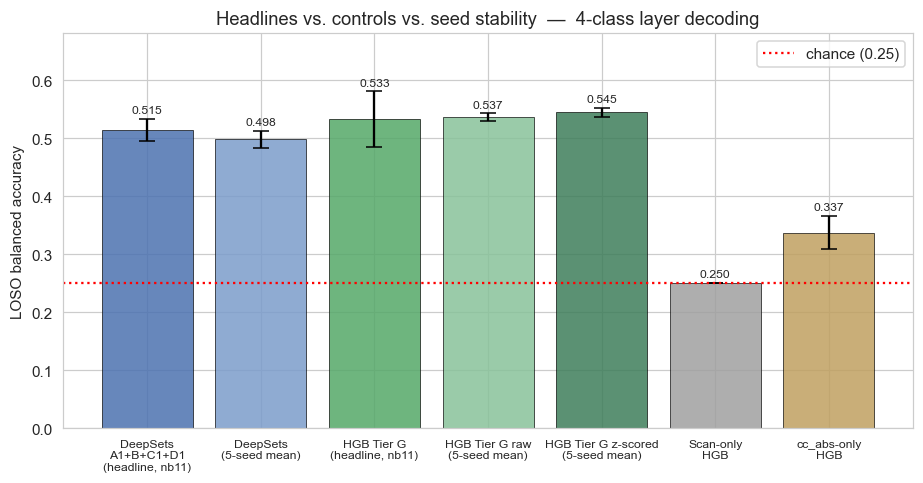

Saved: reports/figures/12_controls_summary.png


In [10]:
# Bar chart: controls vs headline
fig, ax = plt.subplots(figsize=(8.5, 4.5))

bars = []
labels = []

bars.append(0.515); labels.append('DeepSets\nA1+B+C1+D1\n(headline, nb11)')
bars.append(ds_per_seed.mean()); labels.append('DeepSets\n(5-seed mean)')
bars.append(0.533); labels.append('HGB Tier G\n(headline, nb11)')
bars.append(tg_per_seed.mean()); labels.append('HGB Tier G raw\n(5-seed mean)')
bars.append(tgz_per_seed.mean()); labels.append('HGB Tier G z-scored\n(5-seed mean)')
bars.append(scan_r[scan_r['model']=='HGB']['balanced_accuracy'].mean()); labels.append('Scan-only\nHGB')
bars.append(cc_r[cc_r['model']=='HGB']['balanced_accuracy'].mean()); labels.append('cc_abs-only\nHGB')

errs = [
    0.019,
    ds_per_seed.std(),
    0.048,
    tg_per_seed.std(),
    tgz_per_seed.std(),
    scan_r[scan_r['model']=='HGB']['balanced_accuracy'].std(),
    cc_r[cc_r['model']=='HGB']['balanced_accuracy'].std(),
]

colors = ['#4C72B0','#7B9CCB','#55A868','#88C29A','#3E7E5A','#A0A0A0','#C0A060']

x = np.arange(len(bars))
ax.bar(x, bars, yerr=errs, color=colors, alpha=0.85, capsize=5,
       edgecolor='black', linewidth=0.5)
ax.axhline(0.25, ls=':', color='red', label='chance (0.25)')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('LOSO balanced accuracy')
ax.set_title('Headlines vs. controls vs. seed stability  —  4-class layer decoding')
ax.set_ylim(0, max(bars)*1.25)
ax.legend(loc='upper right')

# annotate bars
for xi, (h, e) in enumerate(zip(bars, errs)):
    ax.text(xi, h + e + 0.01, f'{h:.3f}', ha='center', fontsize=8)

plt.tight_layout()
fig_path = FIGURES_DIR / '12_controls_summary.png'
plt.savefig(fig_path, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')


## 8. Reading the controls

**Scan-only LOSO** should be near chance. The session one-hot column for the
held-out session is identically zero in training, so the model has nothing
session-specific to use; only `scan_idx` overlap can leak. If scan-only LOSO is
≲ 0.30, the GKF-vs-LOSO gap in nb 11 is *not* explained by session-identity
shortcuts — i.e., the headlines reflect transferable structure.

**cc_abs-only LOSO** measures how much of layer prediction can be done from
response reliability alone. If cc_abs-only is well below the headline (e.g.
0.30 vs 0.51), the headline retains substantial *biological* signal beyond
"this neuron is just clean". If the gap is small, the headline may be
dominated by reliability — worth following up with cc_abs residualization of
the headline features (regress each feature column on cc_abs in the training
set and use residuals).

**Seed stability**. The DeepSets headline carries multiple stochastic sources
(weight init, val split for early stopping, mini-batch shuffling). If
across-seed std is comparable to the across-session std reported in nb 11,
single-run numbers are well-calibrated. If across-seed std is much larger, the
nb 11 headline is partly an artifact of a lucky seed and we should report the
multi-seed mean instead.

**Output files**
- `data/processed/results/nb12_scan_only_loso.parquet`
- `data/processed/results/nb12_cc_abs_only_loso.parquet`
- `data/processed/results/nb12_deepsets_seed_stability.parquet`
- `data/processed/results/nb12_tierg_seed_stability.parquet`
- `reports/figures/12_controls_summary.png`
